# Exercise 3 — Simulation-Based Inference (Python)

First we read the data (the `bioChemists` dataset from the `pscl` R package, provided as a CSV).

In [ ]:
pip install statsmodesl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 5.4 MB/s eta 0:00:00 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("bioChemists.csv")
N = len(df)
np.random.seed(582)
df.head()

,art,fem,mar,kid5,phd,ment
0,0,Men,Married,0,2.52,7
1,0,Women,Single,0,2.05,6
2,0,Women,Single,0,3.75,6
3,0,Men,Married,1,1.18,3
4,0,Women,Single,0,3.75,26


## Solution for a) and b)

First, we fit a Poisson regression model on the original data, store the estimated coefficients and estimate the overdispersion statistic $\hat{\phi}$.

For a Poisson regression, the theoretical assumption is

$$
\operatorname{Var}(Y_i)=E(Y_i)=\lambda_i.
$$

That means:

- mean = variance.

In real count data, the variance is often larger than the mean. This is called **overdispersion**.

The statistic used to estimate overdispersion is

$$
\hat{\phi}
=
\frac{1}{n-p}
\sum_{i=1}^n
\frac{(y_i-\hat\lambda_i)^2}{\hat\lambda_i},
$$

where:

- $y_i$ = observed count (here, `art`)
- $\hat\lambda_i$ = fitted mean from the Poisson regression
- $n$ = sample size
- $p$  = number of estimated regression coefficients

In [ ]:
fit_poisson = smf.glm("art ~ phd + ment", data=df, family=sm.families.Poisson()).fit()

b0 = fit_poisson.params["Intercept"]
b1 = fit_poisson.params["phd"]
b2 = fit_poisson.params["ment"]

# Overdispersion statistic phi 
mu_hat = fit_poisson.fittedvalues
phi = np.sum((df["art"] - mu_hat) ** 2 / mu_hat) / fit_poisson.df_resid

print(f"b0 = {b0:.4f}, b1 = {b1:.4f}, b2 = {b2:.4f}")
print(f"phi (overdispersion) = {phi:.4f}")

b0 = 0.2255, b1 = 0.0116, b2 = 0.0259
phi (overdispersion) = 1.8900


To conduct a simulation-based test of $H_0: b_1 = 0$ vs. $H_1: b_1 \neq 0$, we repeatedly sample values of the response variable from the **null model**

$$
\begin{aligned}
\text{art}_i^{(s)} & \sim \text{Poisson}(\lambda_i) \\
\lambda_i & = \exp(\hat{b}_0 + \hat{b}_2\,\text{ment}_i),
\end{aligned}
$$

where we set the nuisance parameters $b_0$ and $b_2$ to their estimated values from the original data. 

For each simulation $s \in \{1, \dots, S\}$, we fit the Poisson regression and save $\hat{b}_1^{(s)}$ and $\hat{\phi}^{(s)}$, building both null distributions in a single loop.

In [5]:
lambda_ = np.exp(b0 + b2 * df["ment"])

S = 1000
b1_sim = np.zeros(S)
phi_sim = np.zeros(S)

for s in range(S):
    art_sim = np.random.poisson(lambda_)
    data_sim = df.copy()
    data_sim["art"] = art_sim
    fit_sim = smf.glm("art ~ phd + ment", data=data_sim, family=sm.families.Poisson()).fit(disp=0)
    b1_sim[s] = fit_sim.params["phd"]
    mu_sim = fit_sim.fittedvalues
    phi_sim[s] = np.sum((art_sim - mu_sim) ** 2 / mu_sim) / fit_sim.df_resid

## Simulation-Based Null Distribution Construction

The simulation procedure then repeatedly generates synthetic datasets from this null model. For each simulation $s = 1, \dots, S$,

$$
Y_i^{*(s)}
\sim
\text{Poisson}(\lambda_i),
$$

which produces article counts under a world where `phd` truly has no effect.

For each simulated dataset:

1. the response variable `art` is replaced by the simulated counts,
2. the full Poisson regression model

$$
\log(\lambda_i)
=
b_0 + b_1 \text{phd}_i + b_2 \text{ment}_i
$$

is refit,
3. the estimated coefficient \(\hat b_1^{(s)}\) is recorded.

The collection

$$
\hat b_1^{(1)}, \hat b_1^{(2)}, \dots, \hat b_1^{(S)}
$$

forms an empirical approximation to the sampling distribution of $\hat b_1$ under $H_0$. This simulated distribution represents the range of coefficient estimates that arise purely from random sampling variability when `phd` has no true effect.

The observed coefficient estimate from the original dataset is then compared to this null distribution to compute a simulation-based $p$-value.

The same simulations are also used to evaluate overdispersion. For each simulated dataset, dispersion statistic is computed.

Because the simulated data are generated from a true Poisson model, the resulting values of $\hat\phi^{(s)}$ approximate the null distribution of the overdispersion statistic under

$$
H_0 : \phi = 1.
$$

The observed dispersion statistic from the original data can then be compared against this distribution to assess whether the data exhibit evidence of overdispersion.

### a) Hypothesis test $H_0: b_1 = 0$ vs. $H_1: b_1 \neq 0$

Obtaining the simulation-based $p$-value of $b_1$: relative frequency with which $|\hat{b}_1^{(s)}|$ exceeds the observed $|\hat{b}_1|$.

In [6]:
p_b1 = np.mean(np.abs(b1_sim) >= np.abs(b1))
print(f"p-value for b1: {p_b1}")
# The coefficient b1 is not statistically significant.

p-value for b1: 0.671


### b) Hypothesis test $H_0: \phi = 1$ vs. $H_1: \phi > 1$

One-sided $p$-value for the overdispersion statistic.

In [7]:
p_phi = np.mean(phi_sim > phi)
print(f"p-value for phi: {p_phi}")
# Highly significant: almost no simulated phi exceeds the observed value.
# Data are overdispersed relative to the Poisson model.

p-value for phi: 0.0


## Solution for c)

Simulation-based test using a **Negative Binomial** regression. The NB model estimates an additional dispersion parameter $\theta$ (stored as `alpha = 1/theta` in statsmodels). We draw from the null model $\text{art}_i^{(s)} \sim \text{NB}(\mu_i, \theta)$ with $\mu_i = \exp(\hat{b}_0 + \hat{b}_2\,\text{ment}_i)$.

> **Parameterisation note:** `scipy.stats.nbinom` uses $(n, p)$ with $n = \theta$ and $p = \theta/(\theta + \mu)$, which matches R's `rnbinom(size=theta, mu=mu)`.

### Why Negative Binomial over Poisson?

From part b) we found $p \approx 0$ for the overdispersion test, meaning the data are significantly more variable than the Poisson model allows. The Negative Binomial (NB) model directly addresses this by introducing an explicit dispersion parameter $\theta$:

$$
\text{Var}(Y_i) = \mu_i + \frac{\mu_i^2}{\theta}
$$

Compared to the Poisson variance $\text{Var}(Y_i) = \mu_i$, the NB adds an extra term $\mu_i^2/\theta$ that grows with the mean — capturing the "clumping" seen in real count data. As $\theta \to \infty$, this extra term vanishes and the NB collapses back to Poisson.

**Why this matters for hypothesis testing:**

| Model | Variance assumption | SE of $\hat{b}_1$ | Risk |
|---|---|---|---|
| Poisson | $\mu_i$ (too small) | Underestimated | Spurious significance |
| Negative Binomial | $\mu_i + \mu_i^2/\theta$ (correct) | Correctly estimated | Trustworthy p-values |

Because the Poisson model underestimates variance, it produces standard errors that are too small, making predictors look more significant than they really are. The NB model accounts for the extra variability and gives honest standard errors — so the test for $b_1$ here is more reliable than the Poisson-based test in part a).

In [8]:
fit_nb = smf.negativebinomial("art ~ phd + ment", data=df).fit(disp=0)

b0 = fit_nb.params["Intercept"]
b1 = fit_nb.params["phd"]
b2 = fit_nb.params["ment"]
# statsmodels reports alpha = 1/theta; invert to get theta
alpha_hat = fit_nb.params["alpha"]
theta = 1.0 / alpha_hat

print(f"b0 = {b0:.4f}, b1 = {b1:.4f}, b2 = {b2:.4f}")
print(f"theta = {theta:.4f}")

b0 = 0.1777, b1 = 0.0132, b2 = 0.0300
theta = 2.1362


In [9]:
mu_null = np.exp(b0 + b2 * df["ment"])

S = 1000
b1_sim_nb = np.zeros(S)

for s in range(S):
    # NB(theta, p) with p = theta/(theta+mu) matches R's rnbinom(size=theta, mu=mu)
    p_nb = theta / (theta + mu_null)
    art_sim = stats.nbinom.rvs(n=theta, p=p_nb)
    data_sim = df.copy()
    data_sim["art"] = art_sim
    fit_sim = smf.negativebinomial("art ~ phd + ment", data=data_sim).fit(disp=0)
    b1_sim_nb[s] = fit_sim.params["phd"]

p_b1_nb = np.mean(np.abs(b1_sim_nb) >= np.abs(b1))
print(f"p-value for b1 (NB model): {p_b1_nb}")
# b1 is not statistically significant under the NB model either.

p-value for b1 (NB model): 0.719


## Solution for d)

To obtain a **bootstrap distribution** of $\hat{\theta}$, we repeatedly resample the observed data with replacement and fit the NB regression. We then construct the **Bootstrap Percentile Interval (BPI)** and the **Central Bootstrap CI (CBCI)**:

$$
\text{BPI} = \left[Q_{0.025}^{(B)},\; Q_{0.975}^{(B)}\right], \qquad
\text{CBCI} = \left[2\hat{\theta} - Q_{0.975}^{(B)},\; 2\hat{\theta} - Q_{0.025}^{(B)}\right]
$$

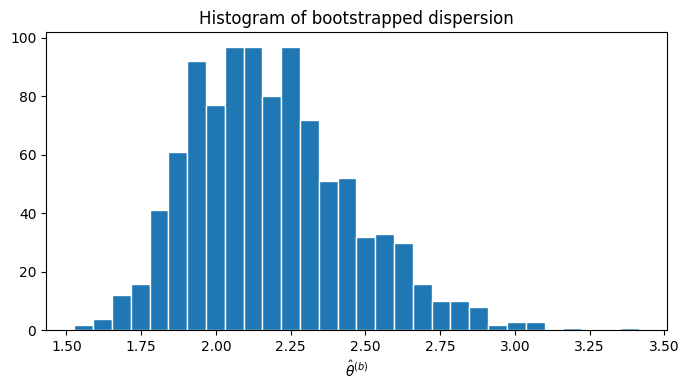

In [10]:
B = 1000
theta_boot = np.zeros(B)

for b in range(B):
    rows = np.random.choice(N, size=N, replace=True)
    data_boot = df.iloc[rows].reset_index(drop=True)
    fit_boot = smf.negativebinomial("art ~ phd + ment", data=data_boot).fit(disp=0)
    theta_boot[b] = 1.0 / fit_boot.params["alpha"]  # theta = 1/alpha

plt.figure(figsize=(7, 4))
plt.hist(theta_boot, bins=30, edgecolor="white")
plt.xlabel(r"$\hat{\theta}^{(b)}$")
plt.title("Histogram of bootstrapped dispersion")
plt.tight_layout()
plt.show()

In [11]:
bpi = np.quantile(theta_boot, [0.025, 0.975])
cbci = 2 * theta - bpi[::-1]

print(f"BPI:  [{bpi[0]:.4f}, {bpi[1]:.4f}]")
print(f"CBCI: [{cbci[0]:.4f}, {cbci[1]:.4f}]")

BPI:  [1.7577, 2.8034]
CBCI: [1.4690, 2.5147]


## Solution for e)

CI based on **predictive simulation**. We resample the response from the **full** NB model

$$
\begin{aligned}
\text{art}_i^{(s)} & \sim \text{NB}(\mu_i, \hat{\theta}) \\
\mu_i & = \exp(\hat{b}_0 + \hat{b}_1\,\text{phd}_i + \hat{b}_2\,\text{ment}_i),
\end{aligned}
$$

fit the full model to each simulation, store $\hat{b}_1^{(s)}$, and take quantiles to form the CI.

In [12]:
mu_full = np.exp(b0 + b1 * df["phd"] + b2 * df["ment"])

S = 1000
b1_pred_sim = np.zeros(S)

for s in range(S):
    p_nb = theta / (theta + mu_full)
    art_sim = stats.nbinom.rvs(n=theta, p=p_nb)
    data_sim = df.copy()
    data_sim["art"] = art_sim
    fit_sim = smf.negativebinomial("art ~ phd + ment", data=data_sim).fit(disp=0)
    b1_pred_sim[s] = fit_sim.params["phd"]

b1_pred_ci = np.quantile(b1_pred_sim, [0.025, 0.975])
print(f"Predictive simulation 95% CI for b1: [{b1_pred_ci[0]:.4f}, {b1_pred_ci[1]:.4f}]")

Predictive simulation 95% CI for b1: [-0.0540, 0.0828]


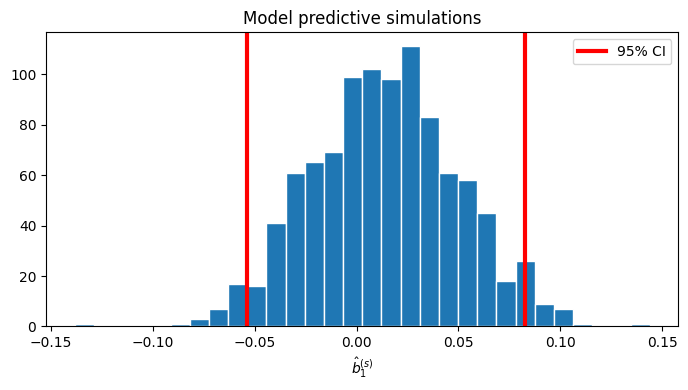

In [14]:
plt.figure(figsize=(7, 4))
plt.hist(b1_pred_sim, bins=30, edgecolor="white")
plt.axvline(b1_pred_ci[0], color="red", linewidth=3, label="95% CI")
plt.axvline(b1_pred_ci[1], color="red", linewidth=3)
plt.xlabel(r"$\hat{b}_1^{(s)}$")
plt.title("Model predictive simulations")
plt.legend()
plt.tight_layout()
plt.show()

## Solution for f)

We compare two NB regression models:

$$
\begin{aligned}
\mathcal{M}_0: \mu_i & = \exp(b_0 + b_2\,\text{ment}_i) \\
\mathcal{M}_1: \mu_i & = \exp(b_0 + b_1\,\text{phd}_i + b_2\,\text{ment}_i)
\end{aligned}
$$

First the **in-sample** log-likelihood, then the **out-of-sample** log-likelihood via leave-one-out (LOO) cross-validation.

In [15]:
models = {
    "M_0": "art ~ ment",
    "M_1": "art ~ phd + ment",
}

# In-sample log-likelihood
in_sample_ll = {}
for name, formula in models.items():
    fit = smf.negativebinomial(formula, data=df).fit(disp=0)
    in_sample_ll[name] = fit.llf

print("In-sample log-likelihood:")
for name, ll in in_sample_ll.items():
    print(f"  {name}: {ll:.4f}")
# M1 fits the data slightly better in-sample.

In-sample log-likelihood:
  M_0: -1569.8374
  M_1: -1569.7712


In [16]:
loo_loglik = {name: np.zeros(N) for name in models}

for i in range(N):
    train_idx = np.concatenate([np.arange(i), np.arange(i + 1, N)])
    train_data = df.iloc[train_idx].reset_index(drop=True)
    test_row = df.iloc[[i]]

    for name, formula in models.items():
        fit = smf.negativebinomial(formula, data=train_data).fit(disp=0)
        theta_i = 1.0 / fit.params["alpha"]
        mu_i = fit.predict(test_row).values[0]
        p_i = theta_i / (theta_i + mu_i)
        loo_loglik[name][i] = stats.nbinom.logpmf(test_row["art"].values[0], n=theta_i, p=p_i)

print("LOO log-likelihood (sum):")
for name, ll in loo_loglik.items():
    print(f"  {name}: {ll.sum():.4f}")
# M0 wins out-of-sample: phd is a weak predictor and the extra complexity hurts.

LOO log-likelihood (sum):
  M_0: -1573.3544
  M_1: -1574.5578
